In [1]:
from src.utils import setup_client

hf_client = setup_client()

### Loading dataset

In [3]:
import pandas as pd

dataset_name = 'college_biology'
splits = {
    'test': f'{dataset_name}/test-00000-of-00001.parquet',
    'validation': f'{dataset_name}/validation-00000-of-00001.parquet',
    'dev': f'{dataset_name}/dev-00000-of-00001.parquet'
}
base_url = "hf://datasets/cais/mmlu/"
df_full = pd.read_parquet(base_url + splits["test"])


In [4]:
df_full

,question,subject,choices,answer
0,Based on the characteristic population curves ...,college_biology,[maintain the population at a point correspond...,2
1,A frameshift mutation is created when,college_biology,"[telomeric sequences are removed from DNA, a c...",2
2,"To prevent desiccation and injury, the embryos...",college_biology,"[amnion, chorion, allantois, yolk sac]",0
3,Which of the following is a second messenger t...,college_biology,"[Prostaglandins, Inositol triphosphate, Cyclic...",1
4,Synthesis of an RNA/DNA hybrid from a single-s...,college_biology,[a DNA or RNA primer and reverse transcriptase...,0
...,...,...,...,...
139,Which of the following is a correct statement ...,college_biology,[The evaporation of water from leaf mesophyll ...,0
140,"In fungi, cell walls are reinforced by which o...",college_biology,"[Chitin, Silica, Lignin, Collagen fibers]",0
141,"In plants, proton pumps are involved in the pr...",college_biology,"[It is passive., It depends on DNA., It requir...",2
142,Which of the following characteristics is pred...,college_biology,[High niche divergence among co-occurring spec...,1


In [68]:
df_full.iloc[12]

question    In Sweden, the red fox (Vulpes vulpes) severel...
subject                                       college_biology
choices     [Both fox and hare populations will decrease.,...
answer                                                      2
Name: 12, dtype: object

In [70]:
# Choose one question and query the model
question_choice = 123 
question = df_full.iloc[question_choice]['question']
choices = df_full.iloc[question_choice]['choices']
answer = df_full.iloc[question_choice]['answer']
# convert 0-based index to letter
answer = chr(answer + ord('A'))

# generate the prompt
choices_text = [f"{letter}. {text}" for letter, text in zip(['A', 'B', 'C', 'D'], choices)]
remark = "Please only answer with a single letter (A, B, C, or D) and nothing else."
prompt = f"{question}\n" + "\n".join(choices_text) + "\n" + remark
print(f"Designed prompt for question {question_choice}:\n")
print("-" * 50)
print(prompt)
print("-" * 50)
print(f"Correct answer: {answer}")


Designed prompt for question 123:

--------------------------------------------------
An organism belonging to the nekton is which one of the following?
A. Whale
B. Barnacle
C. Cyanobacterium
D. Protist
Please only answer with a single letter (A, B, C, or D) and nothing else.
--------------------------------------------------
Correct answer: A


In [36]:
import math
def query_model(prompt, model_name, max_tokens, client):
    content = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        logprobs=True
    )
    # Split the content into a dictionary for each token and its logprobs
    answer = content.choices[0].message.content
    logprobs_content = content.choices[0].logprobs.content
    logprobs_dictionary = {x.token: x.logprob for x in logprobs_content}
    token_prob_dictionary = {token: math.exp(logprobs_dictionary[token]) for token in logprobs_dictionary}
    answer = {
        "answer": answer,
        "logprobs": logprobs_dictionary,
        "token_probs": token_prob_dictionary
    }
    return answer

In [72]:
model_name = "meta-llama/Llama-3.1-8B-Instruct" #"meta-llama/Llama-3.1-8B-Instruct" # "meta-llama/Llama-3.2-1B-Instruct" 

result = query_model(prompt, model_name, max_tokens=5, client=hf_client)

print(f"Model's answer: {result['answer']}")
print("Token probabilities for each token in the answer:")
print(result['token_probs'])
print(f"Correct answer: {df_full.iloc[question_choice]['answer']}")


Model's answer: A
Token probabilities for each token in the answer:
{'A': 0.9999233543037372, '<|eot_id|>': 0.8376133399496174}
Correct answer: 0


In [75]:
models = [
    "meta-llama/Llama-3.1-8B-Instruct",   # current - already working
    "meta-llama/Llama-3.2-1B-Instruct",   # tiny
    "meta-llama/Meta-Llama-3-8B-Instruct", # previous generation
]

for model in models:
    result = query_model(prompt, model, max_tokens=5, client=hf_client)
    print(f"Model: {model}")
    print(f"Model's answer: {result['answer']} | Correct answer: {answer}")
    print(f"Token probs for each token in the answer: {result['token_probs']}")
    print(f"--" * 20)

Model: meta-llama/Llama-3.1-8B-Instruct
Model's answer: A | Correct answer: A
Token probs for each token in the answer: {'A': 0.9999233543037372, '<|eot_id|>': 0.8376133399496174}
----------------------------------------
Model: meta-llama/Llama-3.2-1B-Instruct
Model's answer: D | Correct answer: A
Token probs for each token in the answer: {'D': 0.556565938784693, '': 0.9999924898711537}
----------------------------------------
Model: meta-llama/Meta-Llama-3-8B-Instruct
Model's answer: A | Correct answer: A
Token probs for each token in the answer: {'A': 0.9999860525130737, '<|eot_id|>': 0.9456868156884741}
----------------------------------------


## Testing first 5 rows of dataset

In [83]:
import math
# limit dataset to first 5 rows, just to test
df = df_full.head(50).copy() 

# maps the integer answers from the data set, to the actual letters used in the prompt
ANSWER_MAP = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}



model_name = "meta-llama/Llama-3.1-8B-Instruct" 
max_output_tokens = 5 # only 5 as we just want one single letter as output from the model

results = [] # to store results of api calls

print(f"\nStarting API calls for {len(df)} questions")

# iterate through dataframe
for index, row in df.iterrows(): 

    question_text = row['question'] # the actual question in the dataset
    choices = row['choices'] # the multiple choice options for the answer
    
    # map the integer answer to the actual letter using the premade dictionary ANSWER_MAP
    correct_answer_index = row['answer'] 
    correct_answer_letter = ANSWER_MAP.get(correct_answer_index, 'UNKNOWN') # assign 'UNKNOWN' if correct_answer_index is not either 0, 1, 2, or 3
    
    # make a nice format of the options so that the prompt is correct and easy to read
    option_lines = [f"{letter}. {text}" for letter, text in zip(['A', 'B', 'C', 'D'], choices)]
    
    # construct the final structured prompt
    full_prompt = (
        f"{question_text}\n" + 
        "\n".join(option_lines) +
        "\n\nPlease only answer with a single letter (A, B, C, or D) and nothing else."
    )
    
    # make API call and store log probabilities!
    try:
        result = query_model(full_prompt, model_name, max_tokens=5, client=hf_client)

        
        # Process the response of the model
        final_answer = result['answer']
        logprob_content = result['logprobs'] 
        
        chosen_logprob = result['token_probs'][final_answer] if final_answer in result['token_probs'] else None
        safe_probability = min(chosen_logprob, 1.0) if chosen_logprob is not None else None
        
            
        results.append({
            'id': index,
            'question': question_text,
            'correct_answer': correct_answer_letter,
            'model_answer': final_answer,
            'is_correct': final_answer == correct_answer_letter,
            'chosen_logprob': chosen_logprob,
            'chosen_probability': safe_probability
        })

        answer_is_incorrect = final_answer != correct_answer_letter
        # prints where we are in the iteration and highlight incorrect answers with an asterisk
        if answer_is_incorrect:
            print(f"* Q {index+1}: Correct={correct_answer_letter}, Model={final_answer}, LogProb={chosen_logprob:.10f}, Prob={safe_probability*100:.10f}%")
        else:
            print(f"Q {index+1}: Correct={correct_answer_letter}, Model={final_answer}, LogProb={chosen_logprob:.10f}, Prob={safe_probability*100:.10f}%")

    except Exception as e:
        print(f"Error during API call for Q {index+1}: {e}. Skipping...")
        continue
        
print("\nAPI calls complete.")

# quick analysation of results
results_df = pd.DataFrame(results)
print("\n--- Results Summary (First 5 Questions) ---")
print(f"Total questions processed: {len(results_df)}")
print(f"Overall Accuracy: {results_df['is_correct'].mean():.6f}")



Starting API calls for 50 questions
* Q 1: Correct=C, Model=A, LogProb=0.0449357682, Prob=4.4935768250%
Q 2: Correct=C, Model=C, LogProb=0.9999978542, Prob=99.9997854237%
Error during API call for Q 3: unsupported format string passed to NoneType.__format__. Skipping...
Q 4: Correct=B, Model=B, LogProb=0.9999966622, Prob=99.9996662151%
Q 5: Correct=A, Model=A, LogProb=0.0850751306, Prob=8.5075130570%
Q 6: Correct=A, Model=A, LogProb=0.9942803394, Prob=99.4280339435%
Q 7: Correct=B, Model=B, LogProb=0.9999959469, Prob=99.9995946901%
Q 8: Correct=B, Model=B, LogProb=0.9769609750, Prob=97.6960975014%
Q 9: Correct=D, Model=D, LogProb=0.9999995232, Prob=99.9999523163%
Q 10: Correct=C, Model=C, LogProb=0.9999054760, Prob=99.9905475969%
Error during API call for Q 11: unsupported format string passed to NoneType.__format__. Skipping...
Q 12: Correct=D, Model=D, LogProb=0.8937316348, Prob=89.3731634756%
Q 13: Correct=C, Model=C, LogProb=0.9748163947, Prob=97.4816394743%
Q 14: Correct=D, Model

## Testing out the creation of first calibration plot


Expected Calibration Error (ECE): 0.112422
--------------------------------------------------


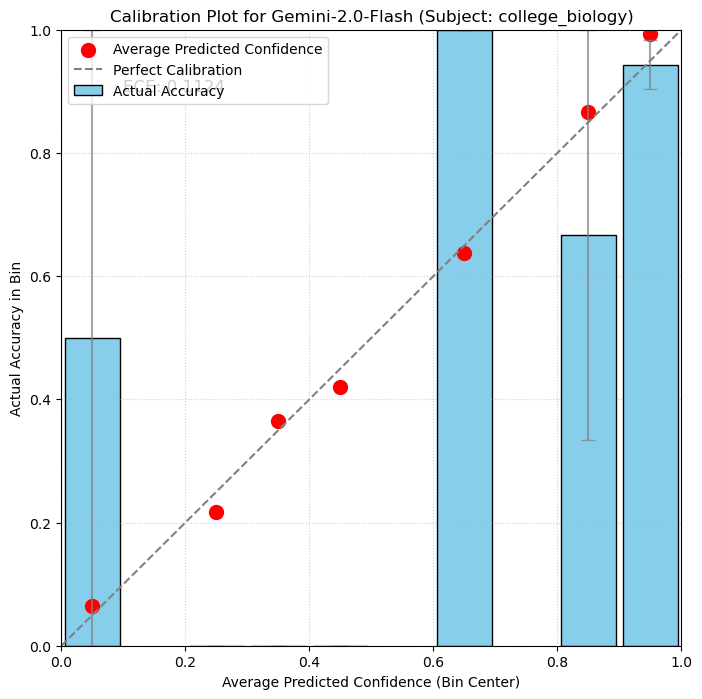

In [95]:
import matplotlib.pyplot as plt
import numpy as np
# Create calibration plot, using the Expected Calibration Error (ECE)
NUM_BINS = 10 
bin_edges = np.linspace(0.0, 1.0, NUM_BINS + 1) 

# ensure there is something in results_df
if len(results_df) == 0:
    print("error: results_df is empty.")
    exit()

# bin the confidence scores, using pd.cut (assigns data values to bins)
results_df['bin'] = pd.cut(
    results_df['chosen_probability'], 
    bins=bin_edges, 
    labels=False, 
    include_lowest=True # whether the first interval should be left-inclusive or not
)

# calculating metrics per bin
calibration_data = results_df.groupby('bin').agg(
    # calculate average predicted probability per bin
    avg_confidence=('chosen_probability', 'mean'),
    # calculate the actual accuracy, using the 'is_correct' boolean in the bin
    avg_accuracy=('is_correct', 'mean'),
    std_accuracy=('is_correct', 'std'), # standard deviation of accuracy in the bin, useful for error bars in the plot
    # count the samples in the bin
    count=('id', 'count') 
).reset_index() # reset_index moves the current index (the values of the 'bin' column) out of the index position and converts it back into a standard df column named 'bin'

# compute standard error of accuracy for error bars in the plot
calibration_data['accuracy_se'] = calibration_data['std_accuracy'] / np.sqrt(calibration_data['count'])
# replace nan values with 0s
calibration_data = calibration_data.fillna(0)

# calculate the center of each bin
def calculate_bin_center(bin_index):
    bin_index = int(bin_index) 
    return (bin_edges[bin_index] + bin_edges[bin_index + 1]) / 2.0

# get correct center for each row
calibration_data['bin_center'] = calibration_data['bin'].apply(calculate_bin_center)


# Calculate ECE!
# first the weights of each bin: (number of samples in bin) / (total number of samples)
calibration_data['weight'] = calibration_data['count'] / calibration_data['count'].sum()

# ECE
calibration_data['ece_term'] = calibration_data['weight'] * np.abs(
    calibration_data['avg_accuracy'] - calibration_data['avg_confidence']
)
ece = calibration_data['ece_term'].sum()

print(f"\nExpected Calibration Error (ECE): {ece:.6f}")
print("-" * 50)


# PLOT
fig, ax = plt.subplots(figsize=(8, 8))

# plot calibration curve (accuracy vs confidence)
ax.bar(
    calibration_data['bin_center'], 
    calibration_data['avg_accuracy'], 
    width=(1/NUM_BINS) * 0.9, # Bar width slightly less than bin width
    color='skyblue', 
    edgecolor='black',
    label='Actual Accuracy'
)

# plot difference between acc and conf
ax.scatter(
    calibration_data['bin_center'],
    calibration_data['avg_confidence'],
    marker='o',
    color='red',
    s=100,
    label='Average Predicted Confidence'
)

ax.errorbar(
    calibration_data['bin_center'],
    calibration_data['avg_accuracy'],
    yerr=calibration_data['accuracy_se'],
    fmt='none',
    ecolor='gray',
    alpha=0.7,
    capsize=5
)

# plot desired perfect calibration line
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

# Set labels and title
ax.set_xlabel('Average Predicted Confidence (Bin Center)')
ax.set_ylabel('Actual Accuracy in Bin')
ax.set_title(f'Calibration Plot for Gemini-2.0-Flash (Subject: {dataset_name})')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

# Add ECE text to the plot
ax.text(0.1, 0.9, f'ECE: {ece:.4f}', transform=ax.transAxes, fontsize=12, 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Display the plot
plt.show()

Text(0, 0.5, 'Actual Accuracy in Bin')

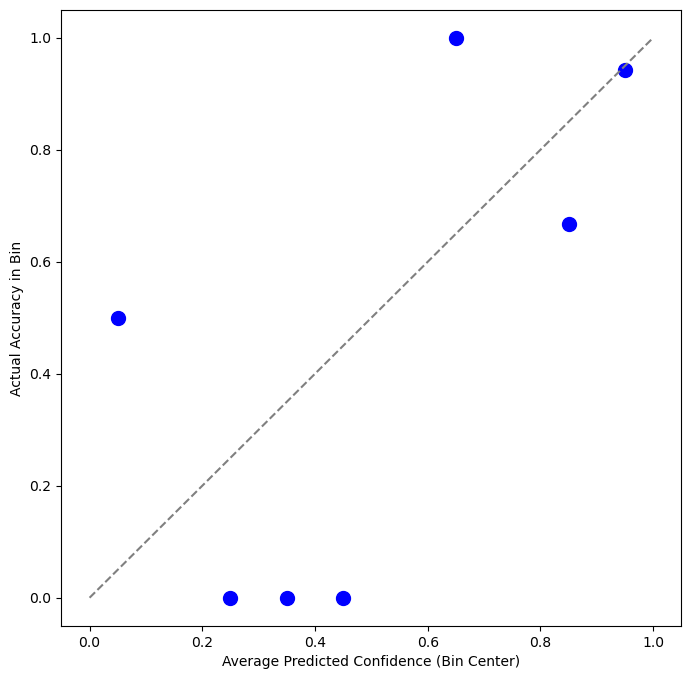

In [85]:
# Plot reliability curve with just scatter points and a dashed line for perfect calibration
fig, ax = plt.subplots(figsize=(8, 8))
# plot the reliability curve (accuracy vs confidence)
ax.scatter(
    calibration_data['bin_center'],
    calibration_data['avg_accuracy'],
    marker='o',
    color='blue',
    s=100,
    label='Actual Accuracy'
)
# plot the perfect calibration line
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
# Set labels and title
ax.set_xlabel('Average Predicted Confidence (Bin Center)')
ax.set_ylabel('Actual Accuracy in Bin')


In [86]:
results_df

,id,question,correct_answer,model_answer,is_correct,chosen_logprob,chosen_probability,bin
0,0,Based on the characteristic population curves ...,C,A,False,0.044936,0.044936,0.0
1,1,A frameshift mutation is created when,C,C,True,0.999998,0.999998,9.0
2,2,"To prevent desiccation and injury, the embryos...",A,A.,False,NaN,NaN,NaN
3,3,Which of the following is a second messenger t...,B,B,True,0.999997,0.999997,9.0
4,4,Synthesis of an RNA/DNA hybrid from a single-s...,A,A,True,0.085075,0.085075,0.0
5,5,In order for the Hardy-Weinberg law to operate...,A,A,True,0.994280,0.994280,9.0
6,6,The Barr body found within female mammalian ce...,B,B,True,0.999996,0.999996,9.0
7,7,Which of the following is NOT a source of atmo...,B,B,True,0.976961,0.976961,9.0
8,8,The concept of punctuated equilibrium refers to,D,D,True,1.000000,1.000000,9.0
9,9,"When an influenza virus enters a cell, it imme...",C,C,True,0.999905,0.999905,9.0


## Defining calibration plot function


In [96]:


# Constants outside the function
ANSWER_MAP = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct" # "meta-llama/Llama-3.1-8B-Instruct" # "meta-llama/Llama-3.2-1B-Instruct"
MAX_OUTPUT_TOKENS = 5 
BASE_URL = "hf://datasets/cais/mmlu/"


def calibration_plot(dataset_name: str, number_of_bins: int):
    """
    Generates a calibration plot for the specified MMLU dataset using the Gemini API.

    Args:
        dataset_name (str): The name of the MMLU dataset subset (e.g., 'college_biology').
        number_of_bins (int): The number of bins to use for the calibration plot.
    """
    import os
    from src.utils import setup_client
    from tqdm import tqdm
    # DATA LOADING
    
    splits = {
        'test': f'{dataset_name}/test-00000-of-00001.parquet',
        'validation': f'{dataset_name}/validation-00000-of-00001.parquet',
        'dev': f'{dataset_name}/dev-00000-of-00001.parquet'
    }
    
    try:
        # Load the FULL dataset for proper calibration (removed .head(5))
        df = pd.read_parquet(BASE_URL + splits["test"])
    except Exception as e:
        print(f"Error loading dataset '{dataset_name}': {e}")
        return

    
    # API SET UP
    
    try:
        # Client needs to be accessible, assuming it's initialized globally or passed in.
        # Since your original code initializes it, we'll assume 'client' is defined here.
        client = setup_client()
        print("HF API Client initialized.")
    except Exception as e:
        print(f"Error when initializing client: {e}")
        return # Use return instead of exit() inside a function

    
    # API CALLS
    
    results = [] # to store results of api calls
    num_questions = len(df)
    print(f"\nStarting API calls for {num_questions} questions in '{dataset_name}'...")

    # iterate through dataframe
    for index, row in tqdm(df.iterrows(), total=num_questions, desc="Answering..."):
        # map the integer answer to the actual letter using the  ANSWER_MAP dict
        correct_answer_index = row['answer'] 
        correct_answer_letter = ANSWER_MAP.get(correct_answer_index, 'UNKNOWN')
        
        # skip if answer is unknown
        if correct_answer_letter == 'UNKNOWN':
            continue

        question_text = row['question'] # the actual question in the dataset
        choices = row['choices'] # the multiple choice options for the answer
        
        # make a nice format of the options so that the prompt is correct and easy to read
        option_lines = [f"{letter}. {text}" for letter, text in zip(['A', 'B', 'C', 'D'], choices)]
        
        # construct the final structured prompt
        full_prompt = (
            f"{question_text}\n" + 
            "\n".join(option_lines) +
            "\n\nPlease only answer with a single letter (A, B, C, or D) and nothing else."
        )
        
        # make API call and store log probabilities!
        try:
            result = query_model(full_prompt, MODEL_NAME, max_tokens=MAX_OUTPUT_TOKENS, client=client)
            # Process the response of the model
            final_answer = result['answer']
            logprob_content = result['logprobs']
            chosen_logprob = result['token_probs'][final_answer] if final_answer in result['token_probs'] else None
            safe_probability = min(chosen_logprob, 1.0) if chosen_logprob is not None else None
        
            results.append({
                'id': index,
                'correct_answer': correct_answer_letter,
                'model_answer': final_answer,
                'is_correct': final_answer == correct_answer_letter,
                'chosen_logprob': chosen_logprob,
                'chosen_probability': safe_probability
            })
            
            #if final_answer is None or chosen_logprob is None or safe_probability is None:
            #    print(f"Q {index+1}: WARNING: Model generated no tokens.")

        except Exception as e:
            # catch errors to prevent one single error of stopping entire function
            print(f"Error during API call for Q {index+1}: {e}. Skipping...")
            continue
            
    print("\nAPI calls complete.")

    
    # CALIBRATION
    
    results_df = pd.DataFrame(results)
    
    if len(results_df) == 0:
        print("error: results_df is empty after API calls.")
        return

    # quick analysation of results
    print("\n--- Results Summary ---")
    print(f"Total questions processed: {len(results_df)}")
    print(f"Overall Accuracy: {results_df['is_correct'].mean():.6f}")
    
    # Create calibration plot, using the Expected Calibration Error (ECE)
    bin_edges = np.linspace(0.0, 1.0, number_of_bins + 1) 

    # bin the confidence scores, using pd.cut
    results_df['bin'] = pd.cut(
        results_df['chosen_probability'], 
        bins=bin_edges, 
        labels=False, 
        include_lowest=True
    )

    # calculating metrics per bin
    calibration_data = results_df.groupby('bin').agg(
        avg_confidence=('chosen_probability', 'mean'),
        avg_accuracy=('is_correct', 'mean'),
        std_accuracy=('is_correct', 'std'), # standard deviation of accuracy in the bin, useful for error bars in the plot
        count=('id', 'count') 
    ).reset_index()

    # compute standard error of accuracy for error bars in the plot
    calibration_data['accuracy_se'] = calibration_data['std_accuracy'] / np.sqrt(calibration_data['count'])

    # replace nan values with 0s
    calibration_data = calibration_data.fillna(0)

    # calculate the center of each bin
    def calculate_bin_center(bin_index):
        bin_index = int(bin_index) 
        return (bin_edges[bin_index] + bin_edges[bin_index + 1]) / 2.0

    # get correct center for each row
    calibration_data['bin_center'] = calibration_data['bin'].apply(calculate_bin_center)


    # Calculate ECE!
    # first the weights of each bin
    calibration_data['weight'] = calibration_data['count'] / calibration_data['count'].sum()

    # ECE
    calibration_data['ece_term'] = calibration_data['weight'] * np.abs(
        calibration_data['avg_accuracy'] - calibration_data['avg_confidence']
    )
    ece = calibration_data['ece_term'].sum()

    print(f"\nExpected Calibration Error (ECE): {ece:.6f}")
    print("-" * 50)


    # PLOTTING
    
    fig, ax = plt.subplots(figsize=(8, 8))

    # plotting actual accuracy 
    ax.scatter(
        calibration_data['bin_center'],
        calibration_data['avg_accuracy'],
        marker='o',
        color='blue',
        s=100,
        label='Actual Accuracy'
    )

    ax.errorbar(
        calibration_data['bin_center'],
        calibration_data['avg_accuracy'],
        yerr=calibration_data['accuracy_se'],
        fmt='none',
        ecolor='gray',
        alpha=0.7,
        capsize=5
    )


    # Print number of samples in each bin
    for _, row in calibration_data.iterrows():
        count = row['count']
        center = row['bin_center']
        
        if count >= 0:
            # Set y-coordinate to a small fixed value (e.g., 0.02) just above the axis.
            # Use 'va="bottom"' to ensure the text starts at 0.02 and doesn't overlap the axis.
            ax.text(
                center, 
                0.02, # Fixed y-coordinate close to the bottom (X-axis)
                f'N={int(count)}',
                ha='center',       # Horizontal alignment (centered on the bar)
                va='bottom',       # Vertical alignment (text base starts at y=0.02)
                fontsize=9,        
                color='black',
                weight='bold'      # Added bolding for better visibility against the blue bar
            )
            

    # plot desired perfect calibration line
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

    # Set labels and title
    ax.set_xlabel('Average Predicted Confidence (Bin Center)')
    ax.set_ylabel('Actual Accuracy in Bin')
    ax.set_title(f'Calibration Plot for {MODEL_NAME} (Subject: {dataset_name}. Ntot={len(df)}.)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    # Add ECE text to the plot
    ax.text(0.1, 0.9, f'ECE: {ece:.4f}', transform=ax.transAxes, fontsize=12, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # display the plot
    plt.show()




HF API Client initialized.

Starting API calls for 272 questions in 'professional_medicine'...


Answering...:   3%|▎         | 9/272 [00:03<01:54,  2.30it/s]

Q 9: WARNING: Model generated no tokens.


Answering...:   6%|▌         | 15/272 [00:06<01:52,  2.29it/s]

Q 15: WARNING: Model generated no tokens.


...

Q 266: WARNING: Model generated no tokens.


Answering...:  99%|█████████▉| 270/272 [02:11<00:00,  2.01it/s]

Q 270: WARNING: Model generated no tokens.


Answering...: 100%|██████████| 272/272 [02:11<00:00,  2.06it/s]


API calls complete.

--- Results Summary ---
Total questions processed: 272
Overall Accuracy: 0.625000

Expected Calibration Error (ECE): 0.108030
--------------------------------------------------


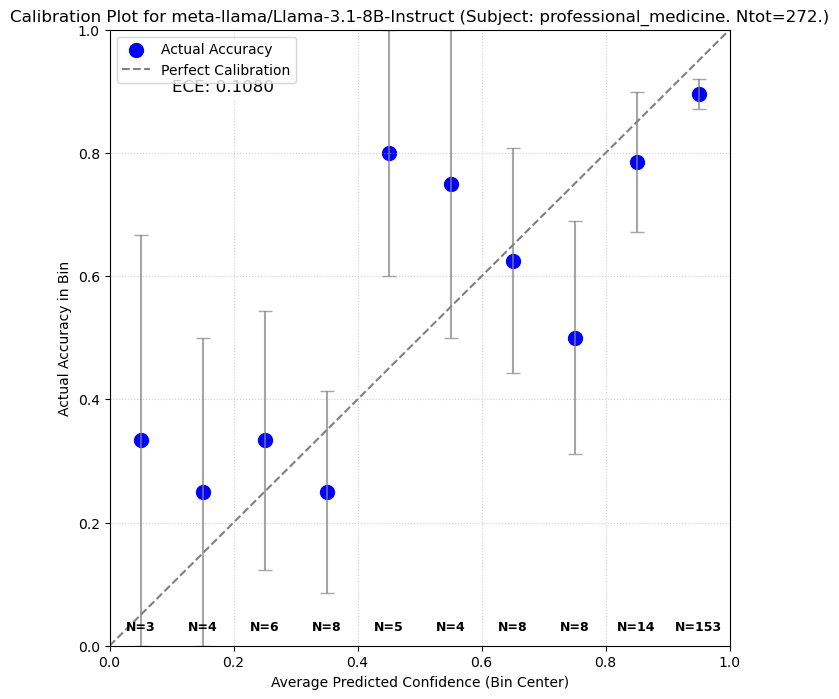

In [97]:
number_of_bins = 10
#data_sets = ['college_biology', 'college_medicine', 'conceptual_physics', 'econometrics', 'high_school_biology', 'high_school_psychology',
 #            'professional_medicine', 'professional_psychology']
data_sets = ["professional_medicine"]
for data_set in data_sets:
    calibration_plot(data_set, number_of_bins)